<a name="outline"></a>

## Outline

- [Task 1](#task-1): Regression
  - [1.1](#q11) Linear regression
  - [1.2](#q12) Ridge regression
  - [1.3](#q13) Relaxation of Lasso regression
- [Task 2](#task-2): Classification
  - [2.1](#q21) kNN classifier
  - [2.2](#q22) Random forest 
  - [2.3](#q23) Support vector machine (SVM) 
- [Task 3](#task-3): Mastery component 
  - [3.1](#q31) Logistic regression and bagging 
  - [3.2](#q32) Kernelised SVM classifier 

<a name="task-1"></a>
# Task 1: Regression [^](#outline)



<a name="q11"></a>

## 1.1 Linear Regression  [^](#outline)

We begin by importing the relevant data and fitting a regression model. The model parameters are printed below.

In [161]:
# Import relevant packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# Import data

chem_samples = pd.read_csv('chemistry_samples.csv')

# Split the data into predictor variables and outcomes

X = chem_samples.iloc[:,0:10]
y = chem_samples['LC50']

# Standardise the predictors

def standardise(X):
    mu = np.mean(X, 0)
    sigma = np.std(X, 0)
    X_std = (X-mu)/(sigma)
    return X_std

X = standardise(X)

def max_lik_estimate(X, y):
    
    # X: N x D matrix of training inputs
    # y: N x 1 vector of training targets/observations
    # returns: maximum likelihood parameters (D x 1)
    
    N, D = X.shape
    beta = np.linalg.pinv(X) @ y
    return beta

# Account for an intercept term

N = X.shape[0]
X_int = np.hstack([np.ones((N,1)), X])

# Obtain the maxlikelihood and prediction

beta = max_lik_estimate(X_int, y)
y_pred = X_int @ beta

print(beta)

[ 4.13993035e+00  3.49957912e-02  5.37535218e-01 -1.50813246e-02
  2.53095451e-01  4.38729982e-03  5.65182177e-01 -2.64033733e-01
 -2.53852943e-01 -7.99453417e-02 -8.28905840e-04]


We now calculate the R^2 statistic using a pre-defined function.

In [162]:
def R_squared(y_pred, y):
    y_bar = np.mean(y)
    SST = np.sum((y-y_bar)**2)
    SSE = np.sum((y-y_pred)**2)
    R = 1 - SSE/SST
    return R

R_squared(y_pred, y)

0.8718259975718016

From this result it appears the model describes a large portion of the variance. We now proceed to apply the model to the test data and compare.

In [163]:
# Import data

chem_test = pd.read_csv('chemistry_test.csv')

# Split the data into predictor variables and outcomes

X_test = chem_test.iloc[:,0:10]
y_test = chem_test['LC50']

# Standardise the data

X_test = standardise(X_test)

# Add an intercept term

N = X_test.shape[0]
X_test_int = np.hstack([np.ones((N,1)), X_test])

# Obtain the prediction

y_pred_test = X_test_int @ beta
R_squared(y_pred_test, y_test)

0.864073774611023

The R^2 statistic for the test set is also very high. This suggests that the model was not overfitted to the training data and so retains its predictive power on unseen data.

<a name="q12"></a>
## 1.2 Ridge Regression[^](#outline)

We begin this section by defining a function to compute the ridge estimate given a penalty term. We then use 5-fold cross validation to tune the hyperparameter. We add a seed to ensure reproducibility of our results.

In [164]:
def beta_ridge(X,y,lam):
    
    # Add an intercept term
    
    N, M = X.shape
    X_aug = np.hstack([np.ones((N,1)), X])
    
    # Calculate the parameters
    
    I = np.identity(M+1)
    beta = (np.linalg.inv(X_aug.T @ X_aug + lam * I)) @ X_aug.T @ y
    return beta

# Create the folds

folds = np.array_split(np.arange(len(y)), 5)

We wish to score each of these folds using the mean square error so we define a function to do this. We then define a function which produces the mean score of given folds. After this, a function is written to seek the best possible choice of lambda.

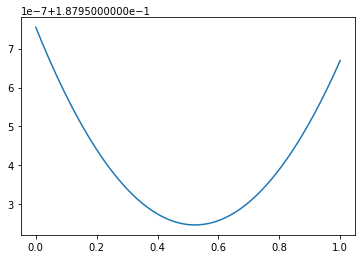

In [165]:
def MSE(y, y_pred):
    MSE = np.sum((y-y_pred)**2)/len(y)
    return MSE

def folds_score(X, y, folds, lam):
    
    score=0
    N=len(folds)
    for i in range(N):
            val_indexes = folds[i]
            train_indexes = list(set(range(y.shape[0])) - set(val_indexes))
            X_train = X.iloc[train_indexes, :]
            y_train = y[train_indexes]
            X_val = X.iloc[val_indexes, :]
            y_val = y[val_indexes]
            
            # Obtain the ridge parameters on the training data
    
            beta = beta_ridge(X_train, y_train, lam)
    
            # Add an intercept term
    
            M = X_val.shape[0]
            X_val_aug = np.hstack([np.ones((M,1)), X_val]) 
            y_pred = X_val_aug @ beta
            score += MSE(y_val, y_pred)
        
    score = score/N
    return score

lam = np.linspace(0,1,100)
lam_scores=np.zeros(len(lam))

for i in range(len(lam)):
    lam_scores[i] = folds_score(X, y, folds, lam[i])

plt.plot(lam, lam_scores)

From the above plot it appears an optimal value of lambda which minimises the MSE is approximately 0.55. Having found an optimal lambda, we now train the ridge regression model on the whole data set. We compute the R^2 statistic and then compare with the test data.

In [166]:
lam = 0.55

beta = beta_ridge(X, y, lam)
y_pred = X_int @ beta
R = R_squared(y_pred, y)
R

0.871825751744659

In [167]:
y_pred_test = X_test_int @ beta
R = R_squared(y_pred_test, y_test)
R

0.8640907181813297

The improvement in the R^2 statistic is negligible.

<a name="q13"></a>

## 1.3 Relaxation of Lasso Regression[^](#outline)




We begin this section by writing two functions which calculate the huber function and its gradient for a given beta.

In [168]:
def huber(beta, c=1e-3):
    if abs(beta) <= c:
        L = 0.5*beta**2
    else:
        L = c*(abs(beta)-0.5*c)
    return L
  
def grad_huber(beta, c=1e-3):
    N=len(beta)
    grad=np.zeros(N)
    for i in range(N):
        if abs(beta[i]) <= c:
            grad[i] = beta[i]
        elif beta[i]>c:
            grad[i] = c
        else:
            grad[i] = -c
    return grad

We now write a function for minimising the cost function using gradient descent methods. We use a default step size of 0.001 during this process.

In [169]:
def minimize_ls_huber(X, y, lam, n_iters=10000, step_size=1e-3):
    n, p = X.shape
    XX = X.T @ X / n
    Xy = X.T @ y / n
    
    # Initialise betas
    beta = np.zeros(p)

    # Gradient descent
    for i in range(n_iters):
        grad = -2*Xy + 2*XX@beta + lam*grad_huber(beta)
        
        # Gradient descent update
        beta = beta - grad*step_size
      
    return beta

We now use 5-fold cross validation to tune the hyperparameter lambda.

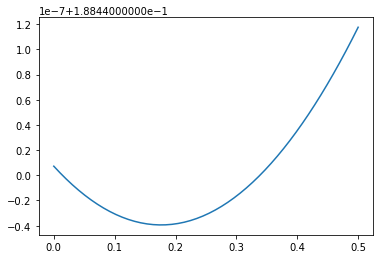

In [171]:
def folds_lasso_score(X, y, folds, lam):
    
    score=0
    N=len(folds)
    for i in range(N):
            val_indexes = folds[i]
            train_indexes = list(set(range(y.shape[0])) - set(val_indexes))
            X_train = X.iloc[train_indexes, :]
            y_train = y[train_indexes]
            X_val = X.iloc[val_indexes, :]
            y_val = y[val_indexes]
            
            # Add an intercept term
            
            p, q = X_train.shape[0], X_val.shape[0]
            X_train_aug = np.hstack([np.ones((p,1)), X_train])
            X_val_aug = np.hstack([np.ones((q,1)), X_val])
            
            # Obtain the ridge parameters on the training data
    
            beta = minimize_ls_huber(X_train_aug, y_train, lam)
    
            # Obtain prediction
    
            y_pred = X_val_aug @ beta
            score += MSE(y_val, y_pred)
        
    score = score/N
    return score

lam = np.linspace(0,0.5,50)
lam_scores=np.zeros(len(lam))

for i in range(len(lam)):
    lam_scores[i] = folds_lasso_score(X, y, folds, lam[i])

plt.plot(lam, lam_scores)

From the above plot, the optimal choice of lambda appears to be 0.175. We now examine the in and out of sample R^2 scores with this choice of lambda.

In [172]:
lam=0.175
beta = minimize_ls_huber(X_int, y, lam)
y_pred = X_int @ beta
R = R_squared(y_pred, y)
R, beta

(0.8714465364075832,
 array([ 4.13984284,  0.07644237,  0.50277039, -0.04354813,  0.25088622,
         0.01484233,  0.56452586, -0.23711466, -0.2114381 , -0.07146709,
         0.03308986]))

In [173]:
y_pred_test = X_test_int @ beta
R = R_squared(y_pred_test, y_test)
R

0.8639108113698988

As with the ridge regression, we do not see any significant improvement in the R^2 statistic.

<a name="task-2"></a>

# Task 2: Classification [^](#outline)

<a name="q21"></a>

## 2.1 kNN Classifier [^](#outline)

In this section we implement a k-nearest neighbours function for classification. We first load in the data and standardise it. The standardisation is essential because without it, predictors with larger quantities will always be deemed further away by the Euclidean metric. Upon inspecting the data, we can see that the 1st column is just an index for the sample so we remove this. We then change the diagnosis columns to 0's and 1's. This means that when the probability of a sample being malignant can easily be classified by rounding to the nearest integer.

In [196]:
# Load the data

tumour_samples = pd.read_csv('tumour_samples.csv')

# Classify benign as 0 and malignant as 1

tumour_samples['DIAGNOSIS'].replace(['B', 'M'], [0, 1], inplace=True)

# Convert to an array

tumour_samples = np.asarray(tumour_samples)

# Split the data into predictors and outcomes
# Exclude 1st column of X because it is just the index, it serves no use
X = tumour_samples[:,1:31]
y = tumour_samples[:,31]
X = standardise(X)

# Function to measure Euclidean distance

def euclidean_distance(p, q):
    return np.sqrt(((q-p)**2).sum(axis=1))

# Find the k-nearest neighbours

def k_neighbours(X_train, X_val, k=5, return_distance=False):
    n_neighbours = k
    dist = []
    neigh_ind = []
  
    # Compute distance from each point x in the validation set to all points in the training set
    
    N = X_val.shape[0]
    point_dist = [euclidean_distance(X_val[n,:], X_train) for n in range(N) ]

    # Determine which k training points are closest to each validation point
    
    for row in point_dist:
    
        enum_neigh = enumerate(row)
        sorted_neigh = sorted(enum_neigh, key=lambda x: x[1])[:k]

        ind_list = [tup[0] for tup in sorted_neigh]
        dist_list = [tup[1] for tup in sorted_neigh]

        dist.append(dist_list)
        neigh_ind.append(ind_list)

        # Return distances together with indices of k nearest neighbours
        
        if return_distance:
            return np.array(dist), np.array(neigh_ind)
    return np.array(neigh_ind)

# Define a function for classifying the data

def predict(X_train, y_train, X_test, k=5):
    
    # each of the k neighbours contributes equally to the classification of any data point in X_test
    
    neighbours = k_neighbours(X_train, X_test, k=k)
    
    # count number of occurences of label with np.bincount and choose the label that has most with np.argmax
    
    M = len(neighbours)
    y_pred = np.array([ np.argmax(np.bincount(np.array(y_train[neighbours[m]], dtype=int))) for m in range(M)])
    return y_pred

# Define a score function

def score(X_train, y_train, X_test, y_test, k=5):
    y_pred = predict(X_train, y_train, X_test, k=k)
    return np.mean(y_pred==y_test)

# Define a score for cross validation

def cross_validation_score(X_train, y_train, folds, k):
    scores = []
    for i in range(len(folds)):
        val_indexes = folds[i]
        train_indexes = list(set(range(y_train.shape[0])) - set(val_indexes))
    
        X_train_i = X_train[train_indexes, :]
        y_train_i = y_train[train_indexes]

        X_val_i = X_train[val_indexes, :]
        y_val_i = y_train[val_indexes]

        score_i = score(X_train_i, y_train_i, X_val_i, y_val_i, k=k)
        scores.append(score_i)

        # Return the average score
        ans = np.mean(scores)
        
        return ans
    
# Define the folds

folds = np.array_split(np.arange(len(y)), 5)

# Grid search for optimal value of k

def choose_best_k(X_train, y_train, folds, k_range):
    k_scores = np.zeros((len(k_range),))
    
    for i, k in enumerate(k_range):
        k_scores[i] = cross_validation_score(X_train, y_train, folds, k)
        print(f'CV_ACC@k={k}: {k_scores[i]:.3f}')

        best_k_index = np.argmax(k_scores)
    return k_range[best_k_index]

best_k = choose_best_k(X, y, folds, np.arange(1, 11))

print('best_k:', best_k)


CV_ACC@k=1: 0.990
CV_ACC@k=2: 0.979
CV_ACC@k=3: 0.979
CV_ACC@k=4: 0.977
CV_ACC@k=5: 0.977
CV_ACC@k=6: 0.977
CV_ACC@k=7: 0.977
CV_ACC@k=8: 0.977
CV_ACC@k=9: 0.977
CV_ACC@k=10: 0.973
best_k: 1


It appears from the above that the optimal value for k is 1. We now train the model with k=1 and test it on both the training and the test data.

In [198]:
# Load in the test data

tumour_test = pd.read_csv('tumour_test.csv')

# Classify benign as 0 and malignant as 1

tumour_test['DIAGNOSIS'].replace(['B', 'M'], [0, 1], inplace=True)

# Convert to an array

tumour_test = np.asarray(tumour_test)

# Split the data into predictors and outcomes
# Exclude 1st column of X because it is just the index, it serves no use

X_test = tumour_test[:, 1:31]
X_test = standardise(X_test)
y_test = tumour_test[:,31]

score(X,y,X,y,k=1), score(X, y, X_test, y_test, k=1)



(1.0, 0.98)

We obtained a 98% accuracy with k=1. This is not as high as the training set which obtained 100%. This is because with k=1 the nearest neighbour to any point is itself so the prediction on the training set will always be 100% in this case. This doesn't tell us much about our model. However, the 98% accuracy on the test set does confirm that the model has excellent predictive abilities on unseen data.

<a name="q22"></a>

## 2.2 Random Forest [^](#outline)

In this section we will train a random forest for classification. We begin by loading in the data and obtaining the feature names which is needed as an input later on.

In [259]:
# Load the data

tumour_samples = pd.read_csv('tumour_samples.csv')

# Classify benign as 0 and malignant as 1

tumour_samples['DIAGNOSIS'].replace(['B', 'M'], [0, 1], inplace=True)
X = tumour_samples.iloc[:,1:31]

# Obtain feature names; this will be needed later on
feature_names = X.columns.tolist()

# Convert the data to an array for ease of use

data = np.asarray(tumour_samples)
X = data[:, 1:31]
y = data[:, 31]

We now define several functions. The first measures the cross entropy. The second splits the samples given a column to split about and a value for the split. The next function finds the optimum split value given a feature and the one after finds the optimum split for any given data set. This is then all combined together in the build_tree function.

In [260]:
# Define a function that measures the cross entropy given the probabilities

def cross_entropy(y, probs):
    
# Probs is an array of probabilities of y being in a given class and a given region.
# len(probs) = no. of classes

    CE = 0
    for i in range(len(probs)):
        if (probs[i]==0):
            CE = 0.
        else:
            CE -= probs[i] * np.log(probs[i])
    return CE

# Now define a function to split the data into two regions based on a predictor and a value for it

def split_samples(X, y, column, value):
    
    left_region = (X[:,column]<value)
    
    X_left, X_right = X[left_region, :], X[~left_region, :]
    y_left, y_right = y[left_region], y[~left_region]
    
    return X_left, X_right, y_left, y_right

# Given a predictor, find the value to split the data which minimises the cross entropy

def CE_split_value(X,y,column):
    unique_vals = np.unique(X[:, column])

    assert len(unique_vals) > 1, f"There must be more than one distinct feature value. Given: {unique_vals}."

    CE_index_val, split_val = np.inf, None
  
    # Split the values of i-th feature and calculate the cross entropy
    
    for value in unique_vals:
        X_l, X_r, y_l, y_r = split_samples(X, y, column, value)

        # If one of the two sides is empty, skip this split
        
        if len(y_l) == 0 or len(y_r) == 0:
            continue
            
        # Obtain probabilities for y belonging to class 0/1 in region l/r
    
        y_l_1 = sum(y_l)
        y_l_0 = len(y_l) - y_l_1
    
        y_r_1 = sum(y_r) 
        y_r_0 = len(y_l) - y_r_1
        
        p_l_0 = y_l_0/(X_l.shape[0])
        p_l_1 = y_l_1/(X_l.shape[0])
        
        p_r_0 = y_r_0/X_r.shape[0]
        p_r_1 = y_r_1/X_r.shape[0]
    
        prob_l = np.array([ p_l_0, p_l_1 ])
        prob_r = np.array([ p_r_0, p_r_1 ])
    
        w_l = len(y_l)/(len(y_l) + len(y_r))
        w_r = 1 - w_l
    
        new_cost = w_l * cross_entropy(y_l, prob_l) + w_r * cross_entropy(y_r, prob_r)
        if new_cost < CE_index_val:
            CE_index_val, split_val = new_cost, value
    
    return CE_index_val, split_val

# Define a function which chooses the best feature to split along

def CE_split(X, y):
    
    # Initialize `split_column` to None, so if None returned this means there is no valid split at the current node.

    min_CE_index, split_column, split_val = np.inf, None, 0
    for column in range(X.shape[1]):
    
        # Skip column if samples are not seperable by that column.
        
        if len(np.unique(X[:, column])) < 2:
            continue
        CE_index, val = CE_split_value(X, y, column)       
        if CE_index < min_CE_index:
            min_CE_index, split_column, split_val = CE_index, column, val

    return split_column, split_val

# Select the majority

def majority_vote(y):
    return np.argmax(np.bincount(np.array(y, dtype='int')))

def build_tree(X, y, feature_names, depth,  max_depth=10, min_samples_leaf=2):
    
    # Include a clause for the cases where (i) no feature, (ii) all labels are the same, (iii) depth exceed, or (iv) X is too small
    if len(np.unique(y))==1 or depth>=max_depth or len(X)<=min_samples_leaf: 
        return {'majority_label': majority_vote(y)}
  
    split_index, split_val = CE_split(X, y)

    # If no valid split at this node, use majority vote.
    
    if split_index is None:
        return {'majority_label': majority_vote(y)}

    X_l, X_r, y_l, y_r = split_samples(X, y, split_index, split_val)
    
    return {
      'feature_name': feature_names[split_index],
      'feature_index': split_index,
      'value': split_val,
      'majority_label': None,
      'left': build_tree(X_l, y_l, feature_names, depth + 1, max_depth, min_samples_leaf),
      'right': build_tree(X_r, y_r, feature_names, depth + 1, max_depth, min_samples_leaf)
  }

We now create functions which predict a classification given some data and a function which scores the accuracy of a given tree.

In [261]:
def classify(tree, x):
    if tree['majority_label'] is not None: 
        return tree['majority_label']
    else:
        if x[tree['feature_index']] < tree['value']:
            return classify(tree['left'], x)
        else:
            return classify(tree['right'], x)

def predict(tree, X):
    if len(X.shape) == 1:
        return classify(tree, X)
    else:
        return np.array([classify(tree, x) for x in X])

def tree_score(tree, X_test, y_test):
    y_pred = predict(tree, X_test)
    return np.mean(y_pred==y_test)

Now we proceed to extend these ideas to make a random forest.

In [262]:
def CE_split_rf(n_features, X, y):

    min_CE_index, split_column, split_val = np.inf, 0, 0
    for column in range(X.shape[1]):
        
        # skip column if samples are not seperable by that column.
        
        if len(np.unique(X[:, column])) < 2:
            continue

        # search for the best splitting value for the given column.
        
        CE_index, val = CE_split_value(X, y, column)      
        if CE_index < min_CE_index:
            min_CE_index, split_column, split_val = CE_index, column, val

    return min_CE_index, split_column, split_val

def build_tree_rf(n_features, X, y, feature_names, depth,  max_depth=10, min_samples_leaf=2):

  # include a clause for the cases where (i) all lables are the same, (ii) depth exceed (iii) X is too small

    if len(np.unique(y)) == 1 or depth>=max_depth or len(X)<=min_samples_leaf: 
        return {'majority_label': majority_vote(y)}
  
    else:
        CE, split_index, split_val = CE_split_rf(n_features, X, y)
    
    # If GI is infinity, it means that samples are not seperable by the sampled features.
        if CE == np.inf:
            return {'majority_label': majority_vote(y)}
        
        X_l, X_r, y_l, y_r = split_samples(X, y, split_index, split_val)
        return {
        'feature_name': feature_names[split_index],
        'feature_index': split_index,
        'value': split_val,
        'majority_label': None,
        'left': build_tree_rf(n_features, X_l, y_l, feature_names, depth + 1, max_depth, min_samples_leaf),
        'right': build_tree_rf(n_features, X_r, y_r, feature_names, depth + 1, max_depth, min_samples_leaf)
    }

Having now defined functions which build a random forest, we now create functions to train one on given data and predict from that. We also define a score function which returns the accuracy, the recall and the F1 score.

In [263]:
def train_rf(B, n_features, feature_names, X, y, depth=1):
    N = X.shape[0]
    training_indices = np.arange(N)
    trees = []

    for _ in range(B):
        sample = np.random.choice(training_indices, N, replace=True)
        X_sample = X[sample, :]
        y_sample = y[sample]
        tree = build_tree_rf(n_features, X_sample, y_sample, feature_names, depth)
        trees.append(tree)
    
    return trees

def predict_rf(rf, X):

    def aggregate(decisions):
        count = defaultdict(int)
        for decision in decisions:
            count[decision] += 1
        return max(count, key=count.get)

    if len(X.shape) == 1:
        return aggregate([classify(tree, X) for tree in rf])
    else:
        return np.array([aggregate([classify(tree, x) for tree in rf]) for x in X])

def rf_score(rf, X_test, y_test):
    y_pred = predict_rf(rf, X_test)
    
    # Obtain false positives, negatives, etc.
    
    TP, TN, FP, FN = 0, 0, 0, 0
    
    for i in range(len(y_pred)):
        if y_pred[i] == y_test[i]:
            if y_pred[i] == 1:
                TP += 1
            else:
                TN += 1
        elif y_pred[i] == 1:
            FP += 1
        else:
            FN += 1
    
    acc = np.mean(y_pred==y_test)
    if TP+FN==0:
        recall = np.nan
    else:
        recall = TP/(TP+FN)
    if TP+FP ==0:
        precision = np.nan
    else:
        precision = TP/(TP+FP)
    if (precision + recall) == 0:
        F1_score = np.nan
    else:
        F1_score = precision * recall /(precision + recall)
    return acc, recall, F1_score

We now implement 5 fold cross validation to select the optimal number of trees and the the optimal depth. We use the same folds as in section 2.1.

In [ ]:
# Same code as before except it calls rf_score instead

def cross_validation_score_rf(X_train, y_train, folds, B, d, feature_names, n_features):
    scores = []
    for i in range(len(folds)):
        
        # First split the data
        
        val_indexes = folds[i]
        train_indexes = list(set(range(y_train.shape[0])) - set(val_indexes))
    
        X_train_i = X_train[train_indexes, :]
        y_train_i = y_train[train_indexes]

        X_val_i = X_train[val_indexes, :]
        y_val_i = y_train[val_indexes]
        
        # Train a rf using the training data
        
        rf = train_rf(B, n_features, feature_names, X_train_i, y_train_i, depth=d,)

        score_i = rf_score(rf, X_val_i, y_val_i)[0]
        scores.append(score_i)

        # Return the average score
        ans = np.mean(scores)
        
        return ans
    
# Here, B is the number of trees

# Implement a nested for loop to scan over different depths and different numbers of trees

def choose_best_B(X_train, y_train, folds, B_range, d_range, feature_names, n_features):
    B_scores = np.zeros((len(B_range), len(d_range)))
    
    for i, B in enumerate(B_range):
        for j, d in enumerate(d_range):
            B_scores[i,j] = cross_validation_score_rf(X_train, y_train, folds, B, d, feature_names, n_features)
            print(f'CV_ACC@B={B}, d={d}: {B_scores[i,j]:.3f}')
            best_B_index = np.argmax(B_scores)
    return B_range[best_B_index]

# Here, d is the depth of the trees

def choose_best_d(X_train, y_train, folds, B, d_range, feature_names, n_features):
    d_scores = np.zeros((len(d_range),))
    
    for i, d in enumerate(d_range):
        d_scores[i] = cross_validation_score_rf(X_train, y_train, folds, B, d, feature_names, n_features)
        print(f'CV_ACC@d={d}: {d_scores[i]:.3f}')

        best_d_index = np.argmax(d_scores)
    return d_range[best_d_index]

We set the number of features in the random forest to be one third of the number of predictors, as is standard practice. We now tune the number of trees. Since the accuracy converges quickly for random forests, we do not need to scan over a large range of values. We will scan for 5 and 10 trees with depths of 5 and 10 respectively.

In [269]:
n_features = X.shape[1] // 3
best_B = choose_best_B(X, y, folds, np.array([5,10]), np.array([5,10]), feature_names, n_features)

C:\Users\ccbar\anaconda3\envs\tf\lib\site-packages\ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in log
  del sys.path[0]


CV_ACC@B=5, d=5: 0.294
CV_ACC@B=5, d=10: nan
CV_ACC@B=10, d=5: nan
CV_ACC@B=10, d=10: nan


The last 3 results returned nan. This occurs whenever the number of true positivies are 0 along with either the flase negatives or the false positives. We will interpret these to be less accurate results. We choose the optimal number of trees to be 5. We now scan over a range of different depths from 1 to 6.

In [272]:
best_d = choose_best_d(X, y, folds, 5, np.arange(1,6), feature_names, n_features)

C:\Users\ccbar\anaconda3\envs\tf\lib\site-packages\ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in log
  del sys.path[0]


CV_ACC@k=1: 0.313
CV_ACC@k=2: nan
CV_ACC@k=3: 0.304
CV_ACC@k=4: nan
CV_ACC@k=5: 0.294


Once again, we will treat the nan results as less accurate. Thus we choose the optimal depth to be 1. Having obtained the optimal values for B and d, we now train a random forest on the entire training data set and compare its accuracy with the test set.

In [273]:
rf = train_rf(5, n_features, feature_names, X, y, depth=1)
rf_score(rf, X, y)

C:\Users\ccbar\anaconda3\envs\tf\lib\site-packages\ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in log
  del sys.path[0]


(0.838269680436477, 0.02122641509433962, 0.020785219399538108)

In [275]:
rf_score(rf, X_test, y_test)

(0.305, 0.40397350993377484, 0.23371647509578547)

From these results we can see that the accuracy of the random forest on the training set is very high. This should be expected. The accuracy on the test set is much worse at 30.5% but it is comparable with the results we obtained when tuning the hyperparameter. The recall and F1 score for the test set are much better than the training set. The recall score indicates that there were many false negatives whilst the F1 score indicates that a poor balance was struck between precision and recall.

<a name="q23"></a>

## 2.3 Support Vector Machine [^](#outline)

In this section we implement an SVM. We reload the data and instead categorise diagnoses by 1 or -1. The positive outcome corresponds to a positive diagnosis. The data is standardised as if it is not, this will influence the choice of the hyperplane. We define a cost function which we seek to minimise via stochastic gradient descent and then train the model on the data.

In [207]:
# Prepare the data and standardise it
# In this section, we instead use +/- 1 for the diagnosis for ease of use when using SVMs.

tumour_samples = pd.read_csv('tumour_samples.csv')
tumour_test = pd.read_csv('tumour_test.csv')

tumour_samples['DIAGNOSIS'].replace(['B', 'M'], [-1, 1], inplace=True)
tumour_test['DIAGNOSIS'].replace(['B', 'M'], [-1, 1], inplace=True)

data = np.asarray(tumour_samples)

X = data[:, 1:31]
y = data[:, 31]
X = standardise(X)

data = np.asarray(tumour_test)

X_test = data[:, 1:31]
y_test = data[:, 31]
X_test = standardise(X_test)

# Compute the cost function

def compute_cost(w, X, y, lam=1e5):
    
    n = X.shape[0]
    distances = 1 - y * (X @ w)
    distances[distances < 0] = 0  # equivalent to max(0, distance)
    hinge = lam * distances.mean() 

    return 0.5 * np.dot(w, w) + hinge

def calculate_cost_gradient(w, X_batch, y_batch, lam=1e5):
    
    # if only one example is passed
    
    if type(y_batch) == np.float64:
        y_batch = np.asarray([y_batch])
        X_batch = np.asarray([X_batch])  # gives multidimensional array

    distance = 1 - (y_batch * (X_batch @ w))
    dw = np.zeros(len(w))

    for ind, d in enumerate(distance):
        if max(0, d)==0:
            di = w
        else:
            di = w - (lam * y_batch[ind] * X_batch[ind])
        dw += di

    return dw/len(y_batch)  # average

# Implement stochastic gradient descent

def sgd(X, y, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=1e5, print_outcome=False):
    
    # initialise zero weights
    weights = np.zeros(X.shape[1])
    nth = 0
    
    # initialise starting cost as infinity
    
    prev_cost = np.inf
  
    # stochastic gradient descent
    
    indices = np.arange(len(y))
    for iteration in range(1, max_iterations):
        
        # shuffle to prevent repeating update cycles
        
        np.random.shuffle(indices)
        X, y = X[indices], y[indices]    
        
        for xi, yi in zip(X, y):
            ascent = calculate_cost_gradient(weights, xi, yi, lam)
            weights = weights - (learning_rate * ascent)

            # convergence check on 2^n'th iteration
            
            if iteration==2**nth or iteration==max_iterations-1:
                
                # compute cost
                cost = compute_cost(weights, X, y, lam)
                
                if print_outcome:
                    print("Iteration is: {}, Cost is: {}".format(iteration, cost))
        
                # stop criterion
                if abs(prev_cost - cost) < stop_criterion * prev_cost:
                    return weights
        
                prev_cost = cost
                nth += 1
  
    return weights

We now define a score function to assess our model's accuracy. The score function also returns the number of false positives and negatives as well as the true positives and negatives. These results will be needed later for plotting an ROC curve.

In [208]:
# To evaluate the mean accuracy in both train and test set, we write a function called score.

def score_svm(w, X, y):
    y_pred = np.sign(X @ w)
    
    # Obtain false positives, negatives, etc.
    
    TP, TN, FP, FN = 0, 0, 0, 0
    
    for i in range(len(y)):
        if y_pred[i] == y[i]:
            if y_pred[i] == 1:
                TP += 1
            else:
                TN += 1
        elif y_pred[i] == 1:
            FP += 1
        else:
            FN += 1
    
    acc = np.mean(y_pred==y)

    return acc, TP, TN, FP, FN

Now we use 5-fold cross validation to tune the value of lambda used in the cost function. We use the same folds as in 2.1.1. We define a folds score function for each fold and a function which implements a grid search to find the best choice of lambda.

In [209]:
def folds_score_svm(X, y, folds, lam, iterations=2000):
    
    score=0
    N=len(folds)
    for i in range(N):
            val_indexes = folds[i]
            train_indexes = list(set(range(y.shape[0])) - set(val_indexes))
            X_train = X[train_indexes, :]
            y_train = y[train_indexes]
            X_val = X[val_indexes, :]
            y_val = y[val_indexes]
            
            # Train the SVM
            
            w = sgd(X_train, y_train, max_iterations=iterations, stop_criterion=0.01, learning_rate=1e-5, lam=lam, print_outcome=False)
            
            score += score_svm(w, X_val, y_val)[0]
 
    score = score/N
    return score

def choose_best_lam(X_train, y_train, folds, lam_range, iterations=2000):
    lam_scores = np.zeros((len(lam_range),))
    
    for i, lam in enumerate(lam_range):
        lam_scores[i] = folds_score_svm(X_train, y_train, folds, lam, iterations=iterations)
        print(f'CV_ACC@lambda={lam}: {lam_scores[i]:.3f}')

        best_lam_index = np.argmax(lam_scores)
    return lam_range[best_lam_index]

In [210]:
best_lam = choose_best_lam(X, y, folds, np.arange(1,31))

CV_ACC@lambda=1: 0.843
CV_ACC@lambda=2: 0.846
CV_ACC@lambda=3: 0.855
CV_ACC@lambda=4: 0.862
CV_ACC@lambda=5: 0.863
CV_ACC@lambda=6: 0.866
CV_ACC@lambda=7: 0.867
CV_ACC@lambda=8: 0.871
CV_ACC@lambda=9: 0.872
CV_ACC@lambda=10: 0.875
CV_ACC@lambda=11: 0.879
CV_ACC@lambda=12: 0.880
CV_ACC@lambda=13: 0.881
CV_ACC@lambda=14: 0.883
CV_ACC@lambda=15: 0.887
CV_ACC@lambda=16: 0.888
CV_ACC@lambda=17: 0.891
CV_ACC@lambda=18: 0.893
CV_ACC@lambda=19: 0.894
CV_ACC@lambda=20: 0.896
CV_ACC@lambda=21: 0.899
CV_ACC@lambda=22: 0.899
CV_ACC@lambda=23: 0.900
CV_ACC@lambda=24: 0.902
CV_ACC@lambda=25: 0.903
CV_ACC@lambda=26: 0.902
CV_ACC@lambda=27: 0.903
CV_ACC@lambda=28: 0.903
CV_ACC@lambda=29: 0.905
CV_ACC@lambda=30: 0.906


In [211]:
print('best_lam:', best_lam)

best_lam: 30


It appears the optimal value is 30. We now investigate the accuracy of the support vector machine for differing values of lambda on the test set. We plot an ROC curve for 50 values of lambda equally spaced between 1 and 1000. The plot is shown below along with the accuracies for the respective values.

In [222]:
lam_range = np.linspace(1,1000,50)

TPR = []
FPR = []
acc = []

for i in lam_range:
    w = sgd(X, y, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=i, print_outcome=False)
    score, TP, TN, FP, FN = score_svm(w, X_test, y_test)
    acc = np.append(acc, score)
    
    if TP+FN == 0:
        TPR = np.nan
    else:
        TPR = np.append( TPR, (TP / (TP+FN)) )
    if TN+FP==0:
        TNR = np.nan
        FPR = np.nan
    else:
        TNR = TN / (TN + FP)
        FPR = np.append( FPR, (1 - TNR) )

acc

array([0.95 , 0.97 , 0.965, 0.965, 0.965, 0.965, 0.96 , 0.95 , 0.965,
       0.95 , 0.96 , 0.96 , 0.945, 0.955, 0.955, 0.95 , 0.955, 0.955,
       0.955, 0.955, 0.955, 0.96 , 0.95 , 0.95 , 0.965, 0.96 , 0.955,
       0.96 , 0.96 , 0.95 , 0.965, 0.95 , 0.96 , 0.96 , 0.95 , 0.965,
       0.96 , 0.96 , 0.97 , 0.955, 0.955, 0.955, 0.955, 0.955, 0.95 ,
       0.945, 0.955, 0.96 , 0.96 , 0.965])

The accuracy is very high for each of these values of lambda. The plot is shown below.

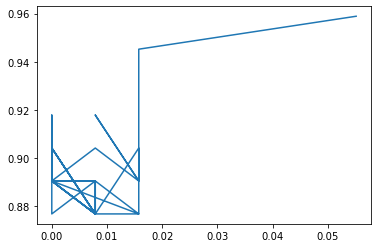

In [223]:
plt.plot(FPR, TPR)

We reproduce the plot below but with the axis range set to 0, 1 for illustrative purposes. We can see that the ROC curve is concentrated in the top right corner of the plot which suggests this range of lambda produces an accurate classifier. The FPR is very low in these cases (close to 0) and the TPR is approximately 90% or more in each case.

(0.0, 1.0)

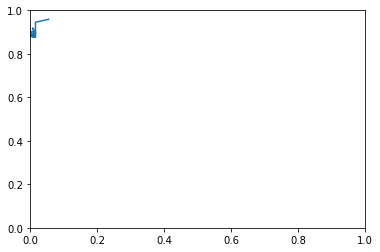

In [224]:
plt.plot(FPR, TPR)
plt.xlim(0,1)
plt.ylim(0,1)

We now repeat this process on the balanced data set.

In [215]:
# Load in the new data and prepare

data=pd.read_csv('tumour_samples_bal.csv')
data['DIAGNOSIS'].replace(['B', 'M'], [-1, 1], inplace=True)
data = np.asarray(data)

X_bal = data[:, 1:31]
y_bal = data[:, 31]
X_bal = standardise(X_bal)

# Create the balanced folds

folds_bal = np.array_split(np.arange(len(y_bal)), 5)

In [217]:
# Tune the hyperparameter

best_lam = choose_best_lam(X_bal, y_bal, folds_bal, np.arange(1,31))

CV_ACC@lambda=1: 0.934
CV_ACC@lambda=2: 0.936
CV_ACC@lambda=3: 0.941
CV_ACC@lambda=4: 0.943
CV_ACC@lambda=5: 0.945
CV_ACC@lambda=6: 0.950
CV_ACC@lambda=7: 0.950
CV_ACC@lambda=8: 0.952
CV_ACC@lambda=9: 0.951
CV_ACC@lambda=10: 0.951
CV_ACC@lambda=11: 0.954
CV_ACC@lambda=12: 0.953
CV_ACC@lambda=13: 0.953
CV_ACC@lambda=14: 0.953
CV_ACC@lambda=15: 0.953
CV_ACC@lambda=16: 0.953
CV_ACC@lambda=17: 0.954
CV_ACC@lambda=18: 0.955
CV_ACC@lambda=19: 0.958
CV_ACC@lambda=20: 0.956
CV_ACC@lambda=21: 0.958
CV_ACC@lambda=22: 0.958
CV_ACC@lambda=23: 0.956
CV_ACC@lambda=24: 0.956
CV_ACC@lambda=25: 0.956
CV_ACC@lambda=26: 0.956
CV_ACC@lambda=27: 0.956
CV_ACC@lambda=28: 0.957
CV_ACC@lambda=29: 0.956
CV_ACC@lambda=30: 0.956


In [218]:
print('best_lam:', best_lam)

best_lam: 19


In this case, we find that lambda=19 is the optimum. Having now obtained the optimal hyperparameter for the SVM on the balanced data set, we now plot an ROC curve for differing values of lambda.

In [220]:
# Run this with max iterations set to 2000

lam_range = np.linspace(1,1000,50)

TPR = []
FPR = []
acc = []

for i in lam_range:
    w = sgd(X_bal, y_bal, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=i, print_outcome=False)
    score, TP, TN, FP, FN = score_svm(w, X_test, y_test)
    acc = np.append(acc, score)
    
    if TP+FN == 0:
        TPR = np.nan
    else:
        TPR = np.append( TPR, (TP / (TP+FN)) )
    if TN+FP==0:
        TNR = np.nan
        FPR = np.nan
    else:
        TNR = TN / (TN + FP)
        FPR = np.append( FPR, (1 - TNR) )

acc

array([0.95 , 0.96 , 0.96 , 0.96 , 0.96 , 0.955, 0.95 , 0.965, 0.96 ,
       0.945, 0.945, 0.94 , 0.94 , 0.945, 0.94 , 0.945, 0.945, 0.94 ,
       0.94 , 0.945, 0.94 , 0.945, 0.94 , 0.94 , 0.945, 0.94 , 0.945,
       0.945, 0.94 , 0.945, 0.945, 0.945, 0.945, 0.95 , 0.95 , 0.945,
       0.945, 0.945, 0.955, 0.94 , 0.94 , 0.94 , 0.945, 0.94 , 0.94 ,
       0.94 , 0.94 , 0.95 , 0.95 , 0.945])

(0.0, 1.0)

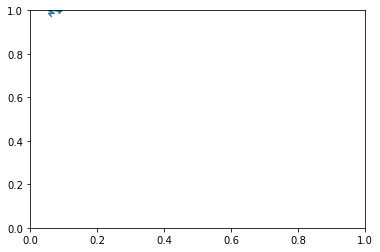

In [221]:
plt.plot(FPR, TPR)
plt.xlim(0,1)
plt.ylim(0,1)

Once again, the ROC curve is excellent. It is concentrated in the top right corner much like the previous one. We can see that the TPR is close to 100% while the FPR is approximately 10%.

<a name="task-3"></a>

# Task 3: Mastery Component [^](#outline)

<a name="q31"></a>

## 3.1 Logistic Regression and Bagging [^](#outline)

In this section we train a logistic regression model for classification. As before, we begin by loading in the data and standardising it. We implement gradient descent and then measure its accuracy.

In [225]:
data=pd.read_csv('tumour_samples.csv')
data['DIAGNOSIS'].replace(['B', 'M'], [0, 1], inplace=True)
data = np.asarray(data)

X = data[:, 1:31]
y = data[:, 31]
X = standardise(X)

data=pd.read_csv('tumour_test.csv')
data['DIAGNOSIS'].replace(['B', 'M'], [0, 1], inplace=True)
data = np.asarray(data)

X_test = data[:, 1:31]
y_test = data[:, 31]
X_test = standardise(X_test)

We now implement gradient descent to minimise the negative log-likelihood function.

In [226]:
def logistic(x):
    return 1. / (1. + np.exp(-x))

def predict_log(X, beta, beta_0):
    y_log = logistic(X @ beta + beta_0)
    return y_log.squeeze()

def propagate(X, y, beta, beta_0):
    y_log = predict_log(X, beta, beta_0)

    # Cost function
    cost = - (y * np.log(y_log) + (1-y) * np.log(1 - y_log)).mean()

    # Derivatives
    
    dbeta = 0
    
    for i in range(len(y)):
        dbeta += X[i,:] * (y_log[i] - y[i])
    
    dbeta = (dbeta/X.shape[0]).reshape(-1,1)
    dbeta_0 =  (y_log - y).mean()

    assert(dbeta.shape==beta.shape)
    assert(dbeta_0.dtype==float)
    cost = np.squeeze(cost)
    assert(cost.shape==())
  
    # store gradients in a dictionary
    grads = {"dbeta": dbeta, "dbeta_0": dbeta_0}
  
    return grads, cost

def optimise(X, y, beta, beta_0, num_iterations=5000, learning_rate=0.005, print_cost=False):
    costs = []
    
    for i in range(num_iterations):

        # calculate cost and gradients
        grads, cost = propagate(X, y, beta, beta_0)
      
        # retrieve derivatives from grads
        dbeta = grads["dbeta"]
        dbeta_0 = grads["dbeta_0"]
      
        # updating procedure
        beta = beta - learning_rate * dbeta
        beta_0 = beta_0 - learning_rate * dbeta_0
      
        # record the costs
        if i % 100 == 0:
            costs.append(cost)
      
        # print the cost every 100 iterations
        if print_cost and i % 100 == 0:
            print ("cost after iteration %i: %f" %(i, cost))
  
    # save parameters and gradients in dictionary
    params = {"beta": beta, "beta_0": beta_0}
    grads = {"dbeta": dbeta, "dbeta_0": dbeta_0}
  
    return params, grads, costs

In [227]:
# Initialise the vector beta and the corresponding scalar

beta = np.zeros(shape = (X.shape[1],1), dtype=float)
beta_0 = 0

parameters, grads, costs = optimise(X, y, beta, beta_0)


We now predict using the model and measure its accuracy on both the training set and the test set.

In [228]:
def predict(X_test, beta, beta_0):
    n = X_test.shape[0]
  
    # compute vector y_log predicting the probabilities
    y_log = predict_log(X_test, beta, beta_0)

    # Returns the probability vector only, need to round to get classification
    return y_log

beta = parameters["beta"]
beta_0 = parameters["beta_0"]

pred_train = predict(X, beta, beta_0).round()
acc_train = np.mean(pred_train == y)

pred_test = predict(X_test, beta, beta_0).round()
acc_test = np.mean(pred_test == y_test)

acc_train, acc_test

(0.9859703819173812, 0.915)

The accuracy for the training and test sets is shown above respectively.

We now implement bagging in order to avoid overfitting our model. We begin by defining a function which implements this.

In [229]:
def bagging(X,y,B,n):
    
    # B = number of samples
    # n = size of each sample, in this case, approx half the total no. of samples

    # First create the random samples

    S = np.zeros(shape=(B,n), dtype='int')
    for i in range(B):
        S[i,:] = np.random.randint(low=0, high=(n-1), size=(n,))

    # Initialise the aggregated probability vector
    
    prob = 0
    beta = np.zeros(shape = (X.shape[1],1), dtype=float)
    beta_0 = []

    # Now create the B models

    for i in range(B):
        X_train = X[(S[i,:]),:]
        y_train = y[(S[i,:])]
    
        beta_sam = np.zeros(shape = (X.shape[1],1), dtype=float)
        beta_0_sam = 0
    
        parameters, grads, costs = optimise(X_train, y_train, beta_sam, beta_0_sam)
    
        beta_sam = parameters["beta"]
        beta_0_sam = parameters["beta_0"]
        
        beta += beta_sam
        beta_0 = np.append(beta_0, beta_0_sam)
    
        prob += predict(X_train, beta_sam, beta_0_sam)
        
    prob = (prob/B).round()
    beta = beta/B
    beta_0 = np.mean(beta_0)
    
    return prob, beta, beta_0

We now use 5-fold cross validation to find the optimum number of samples to use in bagging.

In [230]:
def score_bagging(X_train, y_train, X_val, y_val, B, n):
    pred_train, beta, beta_0 = bagging(X_train, y_train, B, n)
    pred_val = predict(X_val, beta, beta_0).round()
    acc = np.mean(pred_val == y_val)
    return acc

def folds_score_bagging(X, y, folds, B, n):
    
    score=0
    N=len(folds)
    for i in range(N):
            val_indexes = folds[i]
            train_indexes = list(set(range(y.shape[0])) - set(val_indexes))
            X_train = X[train_indexes, :]
            y_train = y[train_indexes]
            X_val = X[val_indexes, :]
            y_val = y[val_indexes]
            
            score += score_bagging(X_train, y_train, X_val, y_val, B, n)
 
    score = score/N
    return score

def choose_best_B(X, y, folds, B_range, n):
    B_scores = np.zeros((len(B_range),))
    
    for i, B in enumerate(B_range):
        B_scores[i] = folds_score_bagging(X, y, folds, B, n)
        print(f'CV_ACC@B={B}: {B_scores[i]:.3f}')

        best_B_index = np.argmax(B_scores)
    return lam_range[best_B_index]

We now scan for the best number of samples. We set the size of each sample to be 2052. This is the size of the data set minus the largest fold.

In [251]:
choose_best_B(X,y,folds, np.array([5,10,15]), 2052)

CV_ACC@B=5: 0.986
CV_ACC@B=10: 0.984
CV_ACC@B=15: 0.984


1.0

The results above show that 5 is the optimal number of samples. We now measure the accuracy of our bagging model compared with the previous one. We set the sample size to be equal to the size of the data set.

In [258]:
score_bagging(X, y, X_test, y_test, 5, 2566)

0.285

The accuracy for this model is significantly worse than the previous. This is an unexpected result and possibly something has gone wrong here.

<a name="q32"></a>

## 3.2 Kernelised SVM Classifier [^](#outline)

In this section we use a kernelised SVM. The code is largely the same as in section 2.3.1 except the cost function is modified and the other functions modified to call these new ones. As before, we use +/-1 for SVM classification.

In [238]:
# Prepare the data and standardise it
# In this section, we instead use +/- 1 for the diagnosis for ease of use when using SVMs.

tumour_test = pd.read_csv('tumour_test.csv')
tumour_test['DIAGNOSIS'].replace(['B', 'M'], [-1, 1], inplace=True)

data=pd.read_csv('tumour_samples_bal.csv')
data['DIAGNOSIS'].replace(['B', 'M'], [-1, 1], inplace=True)
data = np.asarray(data)

X_bal = data[:, 1:31]
y_bal = data[:, 31]
X_bal = standardise(X)

data = np.asarray(tumour_test)

X_test = data[:, 1:31]
y_test = data[:, 31]
X_test = standardise(X_test)

We first create a function for our radial basis function kernel.

In [240]:
def ker(x,y,sigma):
    ans = np.exp((-np.sum((x-y)**2))/sigma)
    return ans

We now modify the previous functions to account for this new kernel.

In [243]:
def compute_cost_ker(w, X, y, sigma, lam=1e5):
    
    n = X.shape[0]
    distances = np.zeros(shape=(n,))
    for i in range(len(y)):
        distances[i] = 1 - y[i] * ker(w, X[i,:], sigma)
        
    distances[distances < 0] = 0  # equivalent to max(0, distance)
    hinge = lam * distances.mean()  

    return 0.5 * ker(w, w, sigma) + hinge

def calculate_cost_gradient_ker(w, X_batch, y_batch, sigma, lam=1e5):
    
    # if only one example is passed
    
    if type(y_batch) == np.float64:
        y_batch = np.asarray([y_batch])
        X_batch = np.asarray([X_batch])  # gives multidimensional array

    n=X_batch.shape[0]
    distance = np.zeros(shape=n)
    for i in range(n):
        distance[i] = 1 - y_batch[i] * ker(w, X_batch[i,:], sigma)

    dw = np.zeros(len(w))

    for ind, d in enumerate(distance):
        if max(0, d)==0:
            di = w
        else:
            di = w - (lam * y_batch[ind] * X_batch[ind,:])
        dw += di

    return dw/n  # average

# Implement stochastic gradient descent

def sgd_ker(X, y, sigma, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=1e5, print_outcome=False):
    
    # initialise zero weights
    weights = np.zeros(X.shape[1])
    nth = 0
    
    # initialise starting cost as infinity
    
    prev_cost = np.inf
  
    # stochastic gradient descent
    
    indices = np.arange(len(y))
    for iteration in range(1, max_iterations):
        
        # shuffle to prevent repeating update cycles
        
        np.random.shuffle(indices)
        X, y = X[indices], y[indices]    
        
        for xi, yi in zip(X, y):
            ascent = calculate_cost_gradient_ker(weights, X, y, sigma, lam)
            weights = weights - (learning_rate * ascent)

            # convergence check on 2^n'th iteration
            
            if iteration==2**nth or iteration==max_iterations-1:
                
                # compute cost
                cost = compute_cost_ker(weights, X, y, sigma, lam)
                
                if print_outcome:
                    print("Iteration is: {}, Cost is: {}".format(iteration, cost))
        
                # stop criterion
                if abs(prev_cost - cost) < stop_criterion * prev_cost:
                    return weights
        
                prev_cost = cost
                nth += 1
  
    return weights

We now train the model on the balanced data set. We set lambda to the optimum found in section 2.3.3. We copy the cross validation code but modify it to call the new functions.

In [244]:
def folds_score_svm_ker(X, y, folds, sigma, lam):
    
    score=0
    N=len(folds)
    for i in range(N):
            val_indexes = folds[i]
            train_indexes = list(set(range(y.shape[0])) - set(val_indexes))
            X_train = X[train_indexes, :]
            y_train = y[train_indexes]
            X_val = X[val_indexes, :]
            y_val = y[val_indexes]
            
            # Train the SVM
            
            w = sgd_ker(X_train, y_train, sigma, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=lam, print_outcome=False)
            
            score += score_svm(w, X_val, y_val)[0]
 
    score = score/N
    return score

def choose_best_sigma(X, y, folds, sigma_range, lam):
    sigma_scores = np.zeros((len(sigma_range),))
    
    for i, sigma in enumerate(sigma_range):
        sigma_scores[i] = folds_score_svm_ker(X, y, folds, sigma, lam)
        print(f'CV_ACC@sigma={sigma}: {sigma_scores[i]:.3f}')

        best_sigma_index = np.argmax(sigma_scores)
    return sigma_range[best_sigma_index]

In [247]:
choose_best_sigma(X_bal, y_bal, folds_bal, np.arange(1,11), 19)

Iteration is: 1, Cost is: 19.501601568444308
Iteration is: 2, Cost is: 19.501541667734266
Iteration is: 1, Cost is: 19.497635801713777
Iteration is: 2, Cost is: 19.497480589942835
Iteration is: 1, Cost is: 19.495428402272097
Iteration is: 2, Cost is: 19.49543291114112
Iteration is: 1, Cost is: 19.490199828688134
Iteration is: 2, Cost is: 19.49020768890178
Iteration is: 1, Cost is: 19.490243953380364
Iteration is: 2, Cost is: 19.4900553298312
CV_ACC@sigma=1: 0.460
Iteration is: 1, Cost is: 19.535226074960107
Iteration is: 2, Cost is: 19.534686789228395
Iteration is: 1, Cost is: 19.525754733096306
Iteration is: 2, Cost is: 19.524775187528267
Iteration is: 1, Cost is: 19.490930166003274
Iteration is: 2, Cost is: 19.490848466693027
Iteration is: 1, Cost is: 19.427445970840868
Iteration is: 2, Cost is: 19.42757735535302
Iteration is: 1, Cost is: 19.433799119687304
Iteration is: 2, Cost is: 19.433411435934275
CV_ACC@sigma=2: 0.460
Iteration is: 1, Cost is: 19.623549943713833
Iteration is: 2,

1

From the above we see no improvement with varying values of sigma. We now train the model with sigma = 1 and measure its accuracy on the test set.

In [248]:
# Add optimum value of sigma

w = sgd_ker(X_bal, y_bal, 1, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=19, print_outcome=True)
score_svm(w, X_test, y_test)[0]

Iteration is: 1, Cost is: 19.4950219791547
Iteration is: 2, Cost is: 19.494977971936617


0.75

The accuracy of this model is much worse than the non-kernelised SVM. The reduction in accuracy would suggest that any patterns in the data classes are inherently linear and so the linear SVM is the more appropriate model in this case.